# <span style="color:darkblue"> Lecture 12: Errors, Exceptions, and User Input </span>

<font size="5">

In the previous class we:
- Wrote one-line **lambda functions**
- Applied a function to a whole DataFrame column with **`.apply()`**
- Wrote functions with no output, like `labeled_bar_plot`

<font size="5">

In this class we will:

- Sort our mistakes into **three kinds** - and see that Python can only catch two of them
- Learn to read a **traceback**: the block of red text Python prints when it gives up
- Keep our code running when something goes wrong, using **`try`** and **`except`**
- Ask the person running our code a question, using **`input()`**

In [1]:
# for convenience, put all import statements here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

<font size="5">

Here are our 50 candidates again, exactly as in Lectures 9, 10, and 11.

In [2]:
lab_partners = {
    "Abed":      {"month": "March",     "day": 23, "year": 2007, "lab_skills": 3.24},
    "Britta":    {"month": "July",      "day": 14, "year": 1998, "lab_skills": 1.51},
    "Jeff":      {"month": "December",  "day": 8,  "year": 1990, "lab_skills": 0.51},
    "Shirley":   {"month": "January",   "day": 19, "year": 1990, "lab_skills": 6.72},
    "Annie":     {"month": "September", "day": 27, "year": 2007, "lab_skills": 6.72},
    "Troy":      {"month": "June",      "day": 5,  "year": 2007, "lab_skills": 3.66},
    "Pierce":    {"month": "December",  "day": 30, "year": 1962, "lab_skills": 0.58},
    "Chang":     {"month": "April",     "day": 17, "year": 1987, "lab_skills": 5.07},
    "Craig":     {"month": "August",    "day": 11, "year": 1985, "lab_skills": 0.37},
    "Magnitude": {"month": "February",  "day": 22, "year": 1983, "lab_skills": 4.34},
    "Garrett":   {"month": "October",   "day": 3,  "year": 2001, "lab_skills": 0.70},
    "Vicki":     {"month": "May",       "day": 29, "year": 2003, "lab_skills": 0.91},
    "Todd":      {"month": "March",     "day": 16, "year": 1997, "lab_skills": 9.99},
    "Starburns": {"month": "July",      "day": 7,  "year": 1982, "lab_skills": 8.27},
    "Neil":      {"month": "January",   "day": 25, "year": 1998, "lab_skills": 1.24},
    "Leonard":   {"month": "November",  "day": 13, "year": 1993, "lab_skills": 2.23},
    "Willy":     {"month": "September", "day": 4,  "year": 1981, "lab_skills": 6.27},
    "Pavel":     {"month": "June",      "day": 21, "year": 1980, "lab_skills": 9.48},
    "Quendra":   {"month": "December",  "day": 9,  "year": 1982, "lab_skills": 5.77},
    "Rich":      {"month": "April",     "day": 28, "year": 1986, "lab_skills": 3.97},
    "Duncan":    {"month": "August",    "day": 15, "year": 1987, "lab_skills": 9.76},
    "Hickey":    {"month": "February",  "day": 6,  "year": 1996, "lab_skills": 0.47},
    "Buzz":      {"month": "October",   "day": 24, "year": 1999, "lab_skills": 8.58},
    "Rachel":    {"month": "May",       "day": 18, "year": 1980, "lab_skills": 2.90},
    "Ian":       {"month": "March",     "day": 12, "year": 1997, "lab_skills": 1.44},
    "Elroy":     {"month": "July",      "day": 30, "year": 1986, "lab_skills": 1.18},
    "Frankie":   {"month": "November",  "day": 2,  "year": 2002, "lab_skills": 3.08},
    "Natalie":   {"month": "September", "day": 20, "year": 2000, "lab_skills": 8.16},
    "Owen":      {"month": "June",      "day": 11, "year": 2002, "lab_skills": 1.81},
    "Paula":     {"month": "December",  "day": 26, "year": 1997, "lab_skills": 5.82},
    "Quinn":     {"month": "April",     "day": 1,  "year": 1993, "lab_skills": 6.39},
    "Roger":     {"month": "August",    "day": 17, "year": 1987, "lab_skills": 3.72},
    "Sara":      {"month": "February",  "day": 8,  "year": 1994, "lab_skills": 5.48},
    "Tim":       {"month": "October",   "day": 22, "year": 1998, "lab_skills": 0.63},
    "Uma":       {"month": "May",       "day": 14, "year": 1988, "lab_skills": 0.60},
    "Victor":    {"month": "January",   "day": 29, "year": 2005, "lab_skills": 2.06},
    "Wendy":     {"month": "July",      "day": 5,  "year": 2007, "lab_skills": 6.80},
    "Xavier":    {"month": "March",     "day": 19, "year": 1980, "lab_skills": 4.28},
    "Yolanda":   {"month": "November",  "day": 10, "year": 2004, "lab_skills": 3.14},
    "Zara":      {"month": "September", "day": 3,  "year": 2005, "lab_skills": 5.86},
    "Alex":      {"month": "June",      "day": 27, "year": 1985, "lab_skills": 4.53},
    "Blake":     {"month": "December",  "day": 16, "year": 2002, "lab_skills": 3.00},
    "Casey":     {"month": "April",     "day": 7,  "year": 1993, "lab_skills": 7.94},
    "Dana":      {"month": "August",    "day": 23, "year": 1990, "lab_skills": 6.99},
    "Eli":       {"month": "February",  "day": 18, "year": 1988, "lab_skills": 2.44},
    "Fiona":     {"month": "October",   "day": 12, "year": 1984, "lab_skills": 5.74},
    "George":    {"month": "May",       "day": 25, "year": 1986, "lab_skills": 5.25},
    "Hana":      {"month": "January",   "day": 6,  "year": 2004, "lab_skills": 8.75},
    "Ivan":      {"month": "July",      "day": 21, "year": 1990, "lab_skills": 7.29},
    "Julia":     {"month": "March",     "day": 15, "year": 1983, "lab_skills": 2.88},
}

months = ["January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"]

print(len(lab_partners), "potential lab partners")

50 potential lab partners


## <span style="color:darkblue"> I. Three kinds of mistakes </span>

<font size = "4">

So far, whenever something has gone wrong in this class, Python has told us about it. That is not always how it works. Everything that can go wrong with your code falls into one of three buckets:

**1. A syntax error.** You typed something that is not Python - a missing colon, an unmatched parenthesis. Python cannot even *read* the cell, so it refuses to run a single line of it.

**2. A runtime error.** The cell is valid Python, so it starts running, but partway through it is asked to do something impossible - look up a name that is not in the dictionary, divide by zero. It stops right there and prints an error message.

**3. A silent error.** The cell runs from top to bottom, prints no complaint whatsoever, and gives you the wrong answer.

The first two are annoying. **The third one is dangerous**, because nothing tells you it happened. Silent errors are the whole subject of next class. Today we deal with the first two.

<font size = "4">

Here are all three, one after another. **Read each cell before you run it** and predict which bucket it lands in.

In [3]:
# Cell A
if lab_partners["Todd"]["lab_skills"] > 9
    print("Todd is a strong candidate")

#Syntax error

SyntaxError: expected ':' (809971829.py, line 2)

In [4]:
# Cell B
# Notice that the first two lines DO run - their output appears above the error message.

print("Looking up Todd...")
print(lab_partners["Todd"]["lab_skills"])

print("Looking up todd...")
print(lab_partners["todd"]["lab_skills"])

print("This last line never runs.")

#Runtime error

Looking up Todd...
9.99
Looking up todd...


KeyError: 'todd'

In [6]:
# Cell C
# We want the strongest candidate in the class.

best_skill = 0
best_name = "nobody"

for name in list(lab_partners.keys()):
    skill = lab_partners[name]["lab_skills"]
    if skill > best_skill:
        best_name = name
        best_skill = skill

print("The strongest candidate is", best_name, "with lab skills", best_skill)

#Silent error
#Never refined best_skill

The strongest candidate is Todd with lab skills 9.99


<font size = "4">

Cell A never ran. Cell B ran halfway and then stopped and complained loudly. Both of those are *fine*: you found out immediately.

Cell C is the frightening one. It printed a grammatical English sentence containing a name and a number, and it did not complain about anything. But we have known since Lecture 9 that the strongest candidate is **Todd**, with 9.99.

Compare Cell C with the running maximum you wrote in Lecture 9, Exercise 2. One line is missing. Which one?

The only reason we caught this is that we already knew the right answer. **That will not usually be true.**

<font size = "4">

You may also have noticed something suspicious about that printed skill of `0`. Nobody in the roster has lab skills of 0 - the weakest candidate, Craig, has 0.37. A number that could not possibly be right is the cheapest bug detector there is, and we will lean on it heavily next class.

## <span style="color:darkblue"> II. Reading a traceback </span>

<font size = "4">

When Python hits a runtime error it prints a **traceback**. It looks like a wall of red text, and most people's instinct is to skim it or ignore it. Do not. It is a short, well-organized report, and it is on your side.

**Read a traceback from the bottom up.**

- The **last line** is the most useful: it names the *type* of error (`KeyError`, `TypeError`, ...) and gives a short message.
- Just above it, Python shows you the **line of code that failed**, with an arrow pointing at it.
- Above *that*, if the failure happened inside a function you called, Python shows the whole chain of calls that got you there - most recent at the bottom.

In [7]:
# Run this and read the message at the very bottom first.

lab_partners["Dunkan"]

KeyError: 'Dunkan'

<font size = "4">

The bottom line says `KeyError: 'Dunkan'`. Python is telling you exactly what it could not find. (In Lecture 9 we asked you to *try* looking up `study_group["abed"]` with a lowercase "a". This is the message you got.)

Now let's see what happens when the error is buried inside a function.

In [8]:
def lab_skills_of(name):
    return lab_partners[name]["lab_skills"]

def compare_two(name_a, name_b):
    skill_a = lab_skills_of(name_a)
    skill_b = lab_skills_of(name_b)
    return round(skill_a - skill_b, 2)

# this one works
print(compare_two("Todd", "Duncan"))

# this one does not
print(compare_two("Todd", "Dunkan"))

0.23


KeyError: 'Dunkan'

<font size = "4">

Look at how many blocks the traceback has. Reading it from the *top* down, it tells a story:

1. The cell called `compare_two`.
2. `compare_two` called `lab_skills_of`.
3. `lab_skills_of` tried `lab_partners[name]` and failed.

This is exactly the chain that "step into" walks you through in debug mode (Lectures 7 and 10). The bottom of the traceback tells you *what* broke; the top tells you *how you got there*.

### A field guide to the errors you will actually meet

<font size = "4">

Every cell below fails **on purpose**. Run them one at a time and read each message. You will see all of these again.

In [9]:
# KeyError -- you asked a dictionary for a key it does not have
lab_partners["Dunkan"]

KeyError: 'Dunkan'

In [10]:
# IndexError -- you asked a list for a position that does not exist.
# There are 50 candidates, so the positions are 0 through 49.

interview_order = list(lab_partners.keys())
interview_order[50]

IndexError: list index out of range

In [11]:
# TypeError -- an operation that makes no sense for these types
"Todd" + 9.99

TypeError: can only concatenate str (not "float") to str

In [12]:
# NameError -- you used a variable that was never created.
# (In Lecture 10 we met this one because "discriminant" was a LOCAL variable.)

print(chosen_skill_of_the_best_candidate)

NameError: name 'chosen_skill_of_the_best_candidate' is not defined

In [13]:
# ValueError -- the right type, but an impossible value.
# float() is happy to convert the string "9.99", but not the string "nine".

print(float("9.99"))
print(float("nine"))

9.99


ValueError: could not convert string to float: 'nine'

In [14]:
# ZeroDivisionError -- this one is a genuine hazard for us.
# In Lecture 7 we estimated the birthday probability by dividing the number of rooms
# that contained a match by the number of rooms we tried. If a bug ever leaves that
# second number at zero:

num_matches = 0
num_trials = 0

print("Estimated probability:", num_matches / num_trials)

ZeroDivisionError: division by zero

<font size = "4">

| Error | What it usually means for us |
|---|---|
| `SyntaxError` | A typo Python cannot read: missing `:`, unbalanced `(` or `"` |
| `IndentationError` | An indented block is misaligned |
| `NameError` | Misspelled a variable, or tried to use a local variable outside its function |
| `KeyError` | Misspelled a name, or looked up a candidate who is not in the roster |
| `IndexError` | Tried to access an index that doesnt exist (often it means you ran a loop one step too far) |
| `TypeError` | Mixed a string and a number, usually because something was never converted |
| `ValueError` | correct data type, but an invalid or inappropriate value for the operation (often means you tried to convert text that is not a number) |
| `ZeroDivisionError` | Divided by a count that turned out to be zero |

### Warnings are not errors

<font size = "4">

There is one more category worth remembering. Back in Lecture 8, Exercise 4, we computed `b**a` and got:

`RuntimeWarning: invalid value encountered in power`

A **warning** does not stop your code. Python mutters something, hands you a `nan`, and carries straight on. That puts warnings halfway between a runtime error and a silent error - and if you scroll past the warning, it becomes a silent error.

In [15]:
# From Lecture 8: a warning, not an error. The cell finishes, and the answer is garbage.

a = np.array([2, 1.2, 3.4])
b = np.array([2.2, -3, 10.01])

f = b**a
print(f)

print("The average of f is", np.mean(f))

[   4.84                 nan 2520.43709866]
The average of f is nan


C:\Users\jndou\AppData\Local\Temp\ipykernel_3140\653356067.py:6: RuntimeWarning: invalid value encountered in power
  f = b**a


<font size = "4">

The average of an array containing `nan` is `nan`. Nothing was raised. If `f` were a column of real data and you plotted it, the plot would simply come out empty and you might blame matplotlib.

## <span style="color:darkblue"> III. `try` and `except` </span>

<font size = "4">

Sometimes an error is not a bug in your code - it is a fact about the world. Somebody is missing from the roster. A count really is zero. In those cases you do not want your whole notebook to stop; you want to handle the situation and carry on.

```python
    try:
        <code that might fail>
    except:
        <what to do if it did>
```

Python runs the `try` block. If nothing goes wrong, the `except` block is skipped entirely. If something *does* go wrong, Python abandons the rest of the `try` block at that exact point and jumps to `except` - and then keeps going with the rest of the cell.

In [16]:
name = "Dunkan"

try:
    skill = lab_partners[name]["lab_skills"]
    print(name, "has lab skills", skill)
except:
    print("I could not find", name, "in the roster.")

print("...and the notebook keeps running.")

I could not find Dunkan in the roster.
...and the notebook keeps running.


<font size = "4">

Change `name` to `"Duncan"` and run it again. Same cell, two different paths through it.

### Name the error you expect

<font size = "4">

A bare `except:` catches **everything** - including the mistakes you did not anticipate. That sounds convenient. It is a trap. The two cells below each contain the same typo: `lab_partner`, missing the "s".

In [17]:
# The lazy version. Read what it tells us.

name = "Todd"

try:
    skill = lab_partner[name]["lab_skills"]
    print(name, "has lab skills", skill)
except:
    print("I could not find", name, "in the roster.")



I could not find Todd in the roster.


<font size = "4">

It says Todd is not in the roster. Todd is the best candidate in the class. Our bare `except` swallowed a two-second typo and replaced it with a confident, wrong sentence.

Now name the error we were actually expecting:

In [ ]:
# The careful version. The typo is a NameError, which we did NOT ask to catch,
# so it surfaces properly and we can go fix it.

name = "Todd"

try:
    skill = lab_partner[name]["lab_skills"]
    print(name, "has lab skills", skill)
except KeyError:
    print("I could not find", name, "in the roster.")

#NameError

NameError: name 'lab_partner' is not defined

<font size = "4">

**Catch the error you expected. Let the ones you did not expect crash.**

### More than one thing can go wrong

<font size = "4">

You can stack several `except` blocks. Python uses the first one that matches.

In [19]:
# In Lecture 9, Jeff went to a lab safety workshop and his score went up by 2.
# Here is a function that reports what somebody's score would be after that workshop.

def show_bonus(name, bonus):
    try:
        skill = lab_partners[name]["lab_skills"]
        print(name, "would have lab skills", skill + bonus, "after the workshop")
    except KeyError:
        print("There is nobody named", name, "in the roster.")
    except TypeError:
        print("The bonus has to be a number. You gave me a", type(bonus))


show_bonus("Jeff", 2.0)
show_bonus("Dunkan", 2.0)
show_bonus("Jeff", "two")

Jeff would have lab skills 2.51 after the workshop
There is nobody named Dunkan in the roster.
The bonus has to be a number. You gave me a <class 'str'>


<font size = "4">

Hold on to that last one. `"two"` is exactly the sort of thing a human being types when you ask them for a number - and in Section IV we are going to start letting human beings type things.

### `try` / `except` inside a loop

<font size = "4">

This is where `try` / `except` earns its keep. The list below came off a paper sign-up sheet, so some of the names are misspelled. We want the average lab skill of the people who signed up, and we do not want one bad name to kill the whole calculation.

In [20]:
sign_up_sheet = ["Todd", "Britta", "Dunkan", "Pavel", "Shirlee", "Vicki", "Buzz"]

found_skills = []

for name in sign_up_sheet:
    try:
        found_skills.append(lab_partners[name]["lab_skills"])
    except KeyError:
        print("Skipping", name, "- not in the roster")

print()
print("Skills I found:", found_skills)
print("Average of the people I could find:", np.mean(found_skills))

Skipping Dunkan - not in the roster
Skipping Shirlee - not in the roster

Skills I found: [9.99, 1.51, 9.48, 0.91, 8.58]
Average of the people I could find: 6.093999999999999


<font size = "4">

Compare this with Lecture 7, where we summed a list containing `None` values:

```python
for value in list_mixed:
    if (type(value) != int) and (type(value) != float):
        print("Warning: Non-numerical element in list!")
        continue
```

Same idea, different tool. The `if` version requires you to *predict every bad case in advance*. The `try` version simply reacts when something actually goes wrong. When you can list the bad cases, use `if`. When you cannot, use `try`.

### The most dangerous two lines in Python

<font size = "4">

Here is the same loop with one small "simplification":

In [21]:
# DO NOT WRITE CODE LIKE THIS

found_skills = []

for name in sign_up_sheet:
    try:
        found_skills.append(lab_partners[name]["lab_skills"])
    except:
        pass

print("Average of the people I could find:", np.mean(found_skills))

Average of the people I could find: 6.093999999999999


<font size = "4">

Exactly the same number comes out, and now nothing on the screen tells you that 2 of the 7 people were thrown away.

Our sign-up sheet has 7 names, so you might spot it. If it had 500 names and 300 of them were misspelled, this cell would quietly average 200 people and present it to you as the average of 500. That is a **silent error**, manufactured on purpose, by us.

`except: pass` says "if anything at all goes wrong, do nothing and tell nobody." **If you catch an error, say so** - print something, or count how many you skipped.

In [ ]:
# A better version: still keeps going, but keeps track

found_skills = []
num_skipped = 0

for name in sign_up_sheet:
    try:
        found_skills.append(lab_partners[name]["lab_skills"])
    except KeyError:
        num_skipped = num_skipped + 1

print("Found", len(found_skills), "people and skipped", num_skipped)
print("Average of the people I could find:", np.mean(found_skills))

### What the plot does not tell you

<font size = "4">

Now let's draw the picture we would actually put in a report.

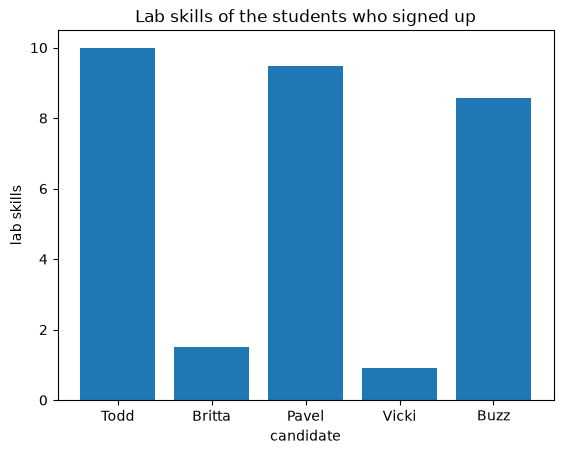

In [22]:
found_names = []
found_skills = []

for name in sign_up_sheet:
    try:
        found_skills.append(lab_partners[name]["lab_skills"])
        found_names.append(name)
    except KeyError:
        pass

plt.bar(x = found_names, height = found_skills)
plt.xlabel("candidate")
plt.ylabel("lab skills")
plt.title("Lab skills of the students who signed up")
plt.show()

<font size = "4">

Seven people signed up. The chart has five bars.

There is nothing *wrong* with the chart. The bars are the right height, the axes are labelled, the title is accurate. And there is absolutely nothing in the picture that tells you two of your seven students are missing - no gap, no gray bar, no footnote. As far as this figure is concerned, Duncan and Shirley never signed up at all.

That is what a silent error looks like from the outside, and it is where we pick up next class.

## <span style="color:darkblue"> IV. Asking a question with `input()` </span>

<font size = "4">

Every number in every program we have written so far was typed into the notebook by *us*. The `input()` function lets the program stop and ask whoever is running it.

When you run the next cell, a small text box appears just underneath it. Type something and press Enter.

**One practical warning.** A cell that is waiting on `input()` has stopped the *whole notebook* - nothing else will run until you answer. If you use "Run All" on a notebook containing `input()`, it will sit there looking frozen. If you get stuck, press the interrupt (stop) button in the toolbar.

In [24]:
answer = input("What is your name? ")

print("Hello,", answer)

Hello, Jeffery Dou


<font size = "4">

`input()` takes one argument - the prompt to display - and returns whatever the person typed.

Now for the single most important fact about it.

In [25]:
answer = input("Type any number you like: ")

print("You typed:", answer)
print("Its type is:", type(answer))

You typed: 12
Its type is: <class 'str'>


<font size = "4">

**`input()` always returns a string.** Always. It does not matter that you typed `42`; you get back the two characters `"4"` and `"2"`.

This is the same "a number stored as text" problem we met all the way back in Lecture 2, and it is going to bite us immediately.

In [26]:
# Run this and type 20 when it asks.

N = input("How many candidates should I interview before setting the benchmark? ")

print("You said N =", N)
print("So half the class would be", N / 2)

You said N = 10


TypeError: unsupported operand type(s) for /: 'str' and 'int'

<font size = "4">

`TypeError`. Right at the bottom of the traceback: you cannot divide a string by a number.

The fix is to convert immediately, on the same line, so that the string never gets a chance to travel any further into your code. Use `int()` for whole numbers and `float()` when decimals are allowed.

In [27]:
# Run this and type 20 again.

N = int(input("How many candidates should I interview before setting the benchmark? "))

print("You said N =", N)
print("Its type is:", type(N))
print("So half the class would be", N / 2)

You said N = 20
Its type is: <class 'int'>
So half the class would be 10.0


<font size = "4">

Now run that same cell again, and this time type `twenty`.

### People type whatever they want

<font size = "4">

`ValueError`, and it is not really the user's fault. It is ours: we wrote code that assumed a cooperative human. This is exactly the situation `try` / `except` was built for, because what someone types is genuinely not under our control.

In [28]:
try:
    N = int(input("How many candidates should I interview first? "))
    print("Great, I will use N =", N)
except ValueError:
    print("That was not a whole number. I will use N = 10 instead.")
    N = 10

print()
print("N =", N)

That was not a whole number. I will use N = 10 instead.

N = 10


### Asking again until they get it right

<font size = "4">

A default value is fine sometimes, but usually we would rather just ask again. We do not know how many times the person will fumble, so a `while` loop is the right shape - and this is one of the rare places where your instructor will admit that a `while` loop is genuinely the natural tool (see Lecture 7, Section IV, for the opposing view).

`while True:` is a loop whose condition is *always* true. The only way out is `break`.

In [29]:
while True:
    typed = input("How many candidates should I interview first? ")

    try:
        N = int(typed)
        break                      # only reached if int() succeeded
    except ValueError:
        print("   ", typed, "is not a whole number. Let's try that again.")

print()
print("N =", N)

    five is not a whole number. Let's try that again.
    seven is not a whole number. Let's try that again.
    aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa is not a whole number. Let's try that again.

N = 10


<font size = "4">

Look carefully at where `break` sits: **inside** the `try` block, on the line after the conversion. If `int(typed)` fails, Python jumps straight to `except` and never reaches the `break`, so the loop goes around again.

Run it and fumble a few times on purpose.

### Checking the value, not just the type

<font size = "4">

That loop still has a hole in it. Type `-4`. Type `1000000`. Both are perfectly good whole numbers and both are nonsense answers to our question, so `int()` accepts them happily.

Validating the **type** is not the same as validating the **value**. We need `try` / `except` for the first and a plain `if` for the second.

In [31]:
def ask_for_N(num_candidates):

    largest_allowed = num_candidates - 1

    while True:
        typed = input(f"Choose N, a whole number from 0 to {largest_allowed}: ")

        # Is it a number at all?
        try:
            N = int(typed)
        except ValueError:
            print("   ", typed, "is not a whole number.")
            continue                     # back to the top of the loop; ask again

        # Is it a sensible number?
        if N < 0 or N > largest_allowed:
            print("   ", N, "is out of range.")
            continue

        return N                         # a return statement leaves the loop too!


N = ask_for_N(len(lab_partners))
print()
print("You chose N =", N)

    p is not a whole number.
    10000 is out of range.

You chose N = 12


<font size = "4">

Two things in that function are worth pointing at:

- `continue` (Lecture 7) sends us back to the top of the loop to ask again.
- `return` (Lecture 10) leaves the whole **function**, so it leaves the loop as a side effect. We never needed a `break` at all.

Every piece of that function is something you already knew how to write two weeks ago. The only new ingredient is `try` / `except`.

### Optional: raising an error yourself

<font size = "4">

Sometimes you do not want to *handle* a bad value - you want to refuse it, loudly, so that whoever called your function finds out immediately. The `raise` keyword lets you produce the same kind of error message we spent Section II learning to read.

In [32]:
def skill_of(name):
    # "not in" is the "in" keyword from Lecture 6 with "not" in front of it
    if name not in list(lab_partners.keys()):
        raise ValueError(f"{name} is not one of the 50 candidates.")

    return lab_partners[name]["lab_skills"]


print(skill_of("Todd"))
print(skill_of("Dunkan"))

9.99


ValueError: Dunkan is not one of the 50 candidates.

<font size = "4">

Notice that we are now on the *other* side of Section II: we are the ones writing the message that somebody else will have to read. Make it a useful one.

## <span style="color:darkblue"> Exercises </span>

<font size = "5">

**1.** For each of the four cells below, **predict before running**: does it fail with a syntax error, fail with a runtime error, or run cleanly and give a wrong answer? If it is a runtime error, name the type.

In [ ]:
# 1a
skills = [3.24, 1.51, 0.51]
average = skills[0] + skills[1] + skills[2] / 3
print("The average lab skill is", average)

The average lab skill is 4.92


: 

In [ ]:
# 1b
for name in list(lab_partners.keys())
    print(name)

In [ ]:
# 1c
interview_order = list(lab_partners.keys())
for position in range(51):
    print(interview_order[position])

In [ ]:
# 1d
print("Todd's lab skills are " + lab_partners["Todd"]["lab_skills"])

<font size = "5">

**2.** Fix Cell C from Section I so that it correctly reports Todd and 9.99. (One line is missing.)

In [ ]:
best_skill = 0
best_name = "nobody"

for name in list(lab_partners.keys()):
    skill = lab_partners[name]["lab_skills"]
    if skill > best_skill:
        best_name = name

print("The strongest candidate is", best_name, "with lab skills", best_skill)

<font size = "5">

**3.** Write a loop over the list below that prints each person's birthday in the form `Shirley was born on January 19`. Use `try` / `except KeyError` so that the misspelled names produce a message like `No birthday on file for Shirlee` instead of stopping the loop.

At the end, print how many birthdays you found and how many you skipped.

In [ ]:
guest_list = ["Shirley", "Shirlee", "Pavel", "Abed", "Abbed", "Zara"]

# your code here

<font size = "5">

**4.** In Lecture 7 we skipped non-numeric values in a list by checking types by hand. Rewrite the loop below so that it uses `try` / `except TypeError` instead of the `if` statement. Confirm you get the same total.

In [ ]:
list_mixed = [1, 2, None, 4, 11, 2.2, None, None, 3]

list_sum = 0
for value in list_mixed:
    if (type(value) != int) and (type(value) != float):
        print("Warning: Non-numerical element in list!")
        continue

    list_sum = list_sum + value

print(list_sum)

<font size = "5">

**5.** The function below reports the average lab skills of every candidate above some cut-off.

- Run it with `cut_off = 5`. Then run it with `cut_off = 20`.
- What error do you get, and why does it appear for one input but not the other?
- Fix it two ways: once with `try` / `except`, and once with an `if` statement. Which do you prefer here, and why?
- **(Bonus.)** Replace the last line with `return np.sum(strong_skills) / len(strong_skills)`, building `strong_skills` as a list. Run it with `cut_off = 20` again. You now get **no error at all** - just `nan`, exactly as in Lecture 8. Which of those two behaviours would you rather your code had, and why?

In [ ]:
def average_above(cut_off):
    total = 0
    count = 0

    for name in list(lab_partners.keys()):
        skill = lab_partners[name]["lab_skills"]
        if skill > cut_off:
            total = total + skill
            count = count + 1

    return total / count


print(average_above(5))
print(average_above(20))

<font size = "5">

**6.** Write a function `ask_for_skill()` that asks the user to type a lab skills score and keeps asking until they give a number between 0 and 10.

- Use `float()`, not `int()` - scores have decimals.
- Test it by typing `abc`, then `-3`, then `77`, then `6.72`.
- Then use the score they typed: loop over the roster and print how many candidates beat it.

In [ ]:
def ask_for_skill():

    # your code here




    return skill

<font size = "5">

**7.** The cell below reports somebody's season of birth, using the season rules from Lecture 6. It has *two* problems: one that Python will complain about, and one that it will not.

- Run it with `"Pierce"`, then with `"pierce"`. Handle the crash with `try` / `except`.
- Now find the silent one. Write a loop over the whole roster that counts how many candidates land in each season, and print the four counts. There are 50 candidates and four seasons, so the counts should be somewhere near 12 or 13 each. Are they?
- Once you have spotted which season is over-full, look at the four lists and explain exactly why `elif` never gets a chance.

In [ ]:
def season_of(name):
    month = lab_partners[name]["month"]

    if month in ["December", "January", "February", "March"]:
        season = "Winter"
    elif month in ["March", "April", "May"]:
        season = "Spring"
    elif month in ["June", "July", "August"]:
        season = "Summer"
    else:
        season = "Fall"

    return season


print(season_of("Pierce"))

<font size = "5">

**8.** Take your `ask_for_N` function from Section IV and combine it with `run_one_trial` from Lecture 10:

- Ask the user for `N`.
- Ask the user for the number of trials (a whole number of at least 1).
- Run that many trials, collect the chosen skills in a list, and print the average with `np.mean`.

You now have a small interactive program. Hand your laptop to the person next to you and let them try to break it.

In [ ]:
# The trial function from Assignment 4, Exercise 6, so you do not have to go and find it

def run_one_trial(N):

    interview_order = list(lab_partners.keys())
    random.shuffle(interview_order)

    best_of_first_N = 0
    for position in range(N):
        name = interview_order[position]
        skill = lab_partners[name]["lab_skills"]
        if skill > best_of_first_N:
            best_of_first_N = skill

    chosen_name = interview_order[-1]
    for position in range(N, len(interview_order)):
        name = interview_order[position]
        skill = lab_partners[name]["lab_skills"]
        if skill > best_of_first_N:
            chosen_name = name
            break

    chosen_skill = lab_partners[chosen_name]["lab_skills"]

    return chosen_name, chosen_skill


# your code here